# Customer Data Analysis -  Uncovering Hidden Patterns in Consumer Behavior

## Objective
This notebook performs a complete statistical analysis of customer data to understand:
- Customer wealth distribution and demographics
- Product purchasing patterns
- Relationships between variables
- Profile of elite athletes

## Dataset
The dataset contains customer information including demographics, product purchases, and fitness metrics.

## Setting Up Our Workspace

Before we start analyzing, we need to load our tools and data.

**What we're doing:**
- Importing Python libraries (our analysis tools)
- Loading the customer dataset
- Taking a quick peek at what we're working with

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset

df = pd.read_csv('data/dataset-1.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (180, 9)

First few rows:
  Product  Age  Gender  Education MaritalStatus  Usage  Fitness  Income  Miles
0   TM195   18    Male         14        Single      3        4   29562    112
1   TM195   19    Male         15        Single      2        3   31836     75
2   TM195   19  Female         14     Partnered      4        3   30699     66
3   TM195   19    Male         12        Single      3        3   32973     85
4   TM195   20    Male         13     Partnered      4        2   35247     47

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        18

## Task 1: The Wealth Gap - Who's Rich and Who's Not?

**The Big Question:** What does a "typical" customer earn?

Here's the thing - when you hear "average income," you might think that's what most people make. But that's not always true! 

**What we're calculating:**
- **Mean (Average):** Add up everyone's income and divide by the number of people
- **Median (Middle):** Line everyone up by income - the person in the middle is the median
- **Mode (Most Common):** The income that appears most often

**Why this matters:**
If a few millionaires walk into a room of regular folks, the average income shoots up, but most people still earn the same. The median tells us what the "typical" person actually makes.

**What to look for:**
- If Mean > Median: A few rich people are pulling the average up (right-skewed)
- If Mean < Median: A few low earners are pulling the average down (left-skewed)
- If Mean ≈ Median: Pretty balanced distribution

This tells us if we're dealing with a wealthy customer base or if there's a big income gap!

In [2]:
# Calculate statistics
income_mean = df['Income'].mean()
income_median = df['Income'].median()
income_mode = df['Income'].mode()[0]

print("=== INCOME STATISTICS ===")
print(f"Mean Income: ${income_mean:,.2f}")
print(f"Median Income: ${income_median:,.2f}")
print(f"Mode Income: ${income_mode:,.2f}")

# Analysis
print("\n=== ANALYSIS ===")
if income_mean > income_median:
    print("The data is RIGHT-SKEWED (positively skewed).")
    print(f"The mean (${income_mean:,.2f}) is higher than the median (${income_median:,.2f}).")
    print("This indicates that a few high-income customers are pulling the average up.")
    print("The 'typical' customer earns closer to the median value.")
    print("There are likely some wealthy outliers in the dataset.")
elif income_mean < income_median:
    print("The data is LEFT-SKEWED (negatively skewed).")
else:
    print("The data is SYMMETRIC.")

=== INCOME STATISTICS ===
Mean Income: $53,719.58
Median Income: $50,596.50
Mode Income: $45,480.00

=== ANALYSIS ===
The data is RIGHT-SKEWED (positively skewed).
The mean ($53,719.58) is higher than the median ($50,596.50).
This indicates that a few high-income customers are pulling the average up.
The 'typical' customer earns closer to the median value.
There are likely some wealthy outliers in the dataset.


## Task 2: The 5-Number Summary - Mapping the Miles

**The Big Question:** How far are customers traveling, and who are the outliers?

Imagine you're looking at how many miles customers log on their fitness equipment. Some people barely use it, others are training for marathons. The 5-number summary gives us the full picture.

**The 5 Numbers:**
1. **Minimum:** The laziest customer (lowest miles)
2. **Q1 (25th percentile):** 25% of customers are below this
3. **Median (50th percentile):** The middle - half above, half below
4. **Q3 (75th percentile):** 75% of customers are below this
5. **Maximum:** The fitness fanatic (highest miles)

**The Boxplot:**
Think of it as a visual summary. The box shows where most people are, and those dots outside? Those are the outliers - the extreme cases that don't fit the pattern.

**Why outliers matter:**
They could be data errors, or they could be your most dedicated customers. Either way, they're worth investigating!

=== 5-NUMBER SUMMARY FOR MILES ===
Minimum: 21.00
Q1 (25th percentile): 66.00
Median (50th percentile): 94.00
Q3 (75th percentile): 114.75
Maximum: 360.00
IQR (Interquartile Range): 48.75


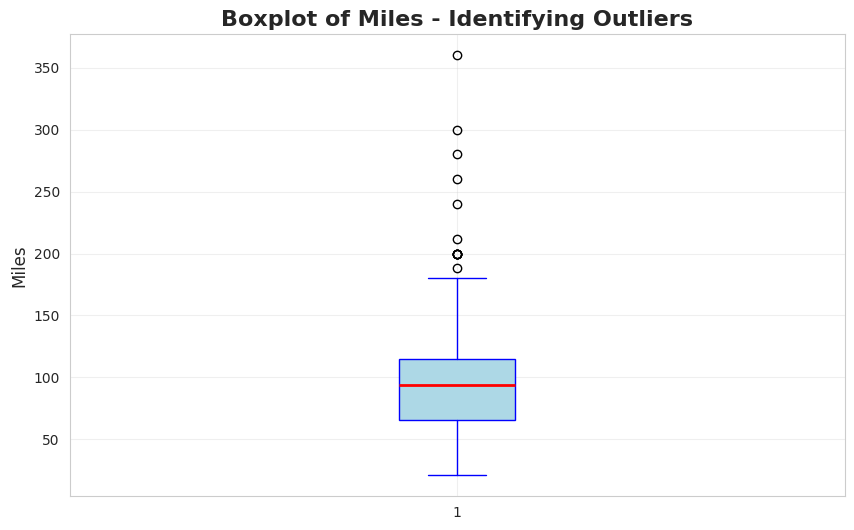


Number of outliers: 13
Outlier values: [np.int64(188), np.int64(200), np.int64(200), np.int64(200), np.int64(200), np.int64(200), np.int64(200), np.int64(212), np.int64(240), np.int64(260), np.int64(280), np.int64(300), np.int64(360)]


In [31]:
# Calculate 5-number summary
miles_min = df['Miles'].min()
miles_q1 = df['Miles'].quantile(0.25)
miles_median = df['Miles'].median()
miles_q3 = df['Miles'].quantile(0.75)
miles_max = df['Miles'].max()

print("=== 5-NUMBER SUMMARY FOR MILES ===")
print(f"Minimum: {miles_min:.2f}")
print(f"Q1 (25th percentile): {miles_q1:.2f}")
print(f"Median (50th percentile): {miles_median:.2f}")
print(f"Q3 (75th percentile): {miles_q3:.2f}")
print(f"Maximum: {miles_max:.2f}")
print(f"IQR (Interquartile Range): {miles_q3 - miles_q1:.2f}")

# Create boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df['Miles'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Boxplot of Miles - Identifying Outliers', fontsize=16, fontweight='bold')
plt.ylabel('Miles', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Identify outliers
iqr = miles_q3 - miles_q1
lower_bound = miles_q1 - 1.5 * iqr
upper_bound = miles_q3 + 1.5 * iqr
outliers = df[(df['Miles'] < lower_bound) | (df['Miles'] > upper_bound)]['Miles']
print(f"\nNumber of outliers: {len(outliers)}")
if len(outliers) > 0:
    print(f"Outlier values: {sorted(outliers.values)}")

## Task 3: Age Distribution - How Old Are Our Customers?

**The Big Question:** What age group dominates our customer base?

We're creating a histogram - basically a bar chart that groups ages into ranges (called "bins"). This shows us at a glance where most of our customers fall.

**What we're doing:**
- Splitting ages into 10 equal ranges
- Counting how many customers fall into each range
- Finding which range contains the median age

**Why 10 bins?**
It's a sweet spot - not too detailed that it's messy, not too broad that we miss patterns.

**What this tells us:**
- Are we attracting young fitness enthusiasts or older health-conscious folks?
- Is there a specific age bracket we should target with marketing?
- Does the median age match our expectations?

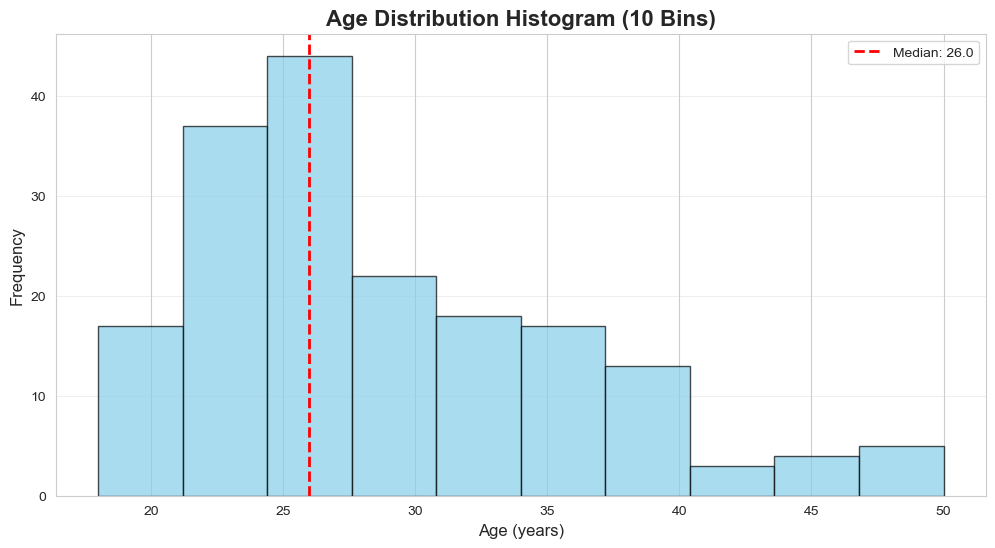


=== AGE ANALYSIS ===
Median Age: 26.0 years

Bin ranges:
Bin 1: 18.0 - 21.2 years (Frequency: 17)
Bin 2: 21.2 - 24.4 years (Frequency: 37)
Bin 3: 24.4 - 27.6 years (Frequency: 44)
  *** MEDIAN FALLS IN THIS BRACKET ***
Bin 4: 27.6 - 30.8 years (Frequency: 22)
Bin 5: 30.8 - 34.0 years (Frequency: 18)
Bin 6: 34.0 - 37.2 years (Frequency: 17)
Bin 7: 37.2 - 40.4 years (Frequency: 13)
Bin 8: 40.4 - 43.6 years (Frequency: 3)
Bin 9: 43.6 - 46.8 years (Frequency: 4)
Bin 10: 46.8 - 50.0 years (Frequency: 5)


In [3]:
# Create histogram
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(df['Age'], bins=10, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(df['Age'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
plt.title('Age Distribution Histogram (10 Bins)', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# Analysis
age_median = df['Age'].median()
print(f"\n=== AGE ANALYSIS ===")
print(f"Median Age: {age_median:.1f} years")
print(f"\nBin ranges:")
for i in range(len(bins)-1):
    print(f"Bin {i+1}: {bins[i]:.1f} - {bins[i+1]:.1f} years (Frequency: {int(n[i])})")
    if bins[i] <= age_median < bins[i+1]:
        print(f"  *** MEDIAN FALLS IN THIS BRACKET ***")

## Task 4: Product Popularity 

**The Big Question:** Which product is the crowd favorite?

We have three products: TM195, TM498, and TM798. Let's see which one customers love the most!

**What we're doing:**
- Counting how many times each product was sold
- Creating a bar chart to visualize the results
- Identifying the winner (and the loser)

**Why this matters:**
- **For inventory:** Stock more of what sells
- **For marketing:** Promote the underdog or double down on the winner
- **For product development:** Understand what features customers prefer



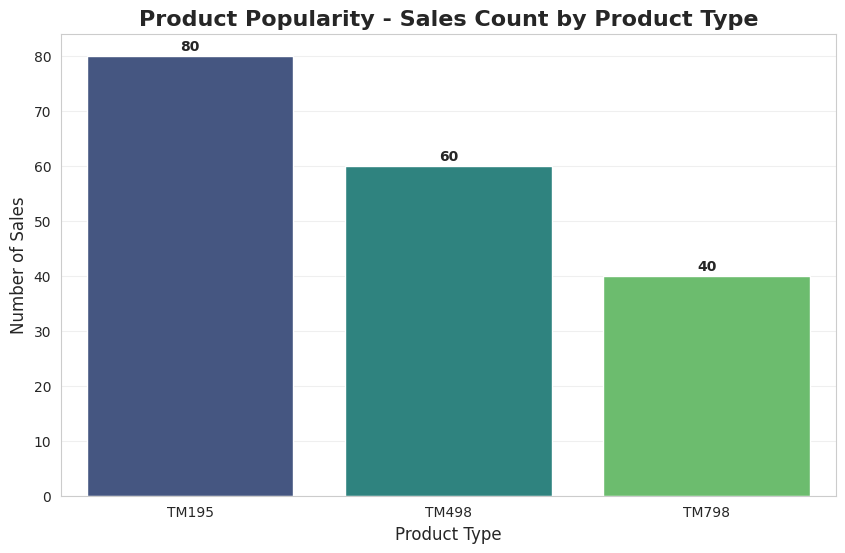

=== PRODUCT SALES ===
Product
TM195    80
TM498    60
TM798    40
Name: count, dtype: int64


In [34]:
plt.figure(figsize=(10, 6))
product_counts = df['Product'].value_counts()
sns.countplot(data=df, x='Product',hue='Product',palette='viridis', order=product_counts.index,dodge=False)
plt.title('Product Popularity - Sales Count by Product Type', fontsize=16, fontweight='bold')
plt.xlabel('Product Type', fontsize=12)
plt.ylabel('Number of Sales', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, v in enumerate(product_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.show()

print("=== PRODUCT SALES ===")
print(product_counts)

## Task 5: Income vs Product - Who Buys What?

**The Big Question:** Are certain products targeted at wealthier customers?

Not all products are created equal. Some are budget-friendly, others are premium. Let's see if there's a clear income divide between product buyers.

**What we're doing:**
- Creating boxplots to compare income across the three products
- Looking at median incomes (the middle earner for each product)
- Identifying which product attracts the high rollers

**How to read the boxplot:**
- Higher box = Higher income customers
- Wider box = More income variety
- Dots outside = Unusual cases (very rich or very poor buyers)

**Business insight:**
If TM798 buyers earn way more than TM195 buyers, we know TM798 is the "luxury" model. This helps with pricing, marketing, and positioning strategies.


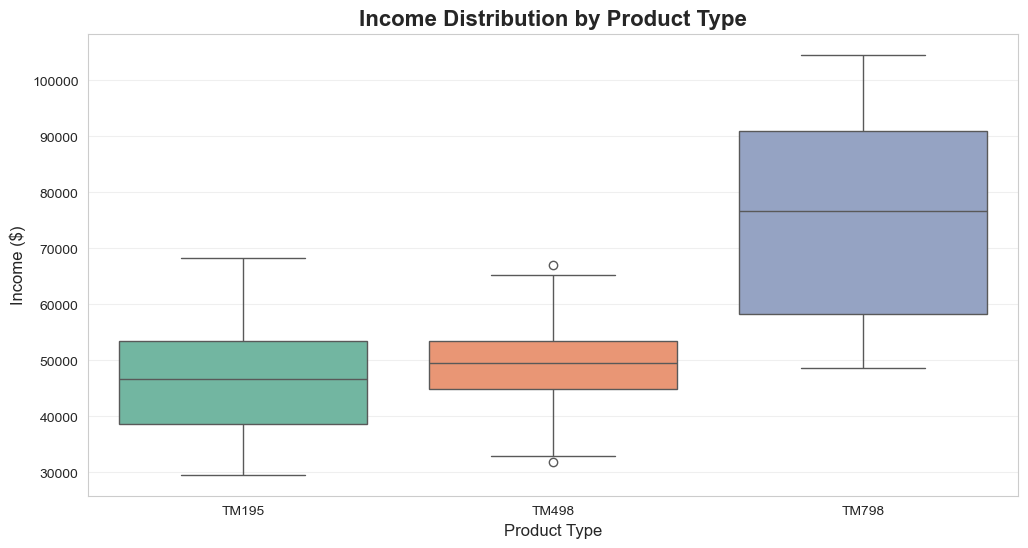

=== INCOME BY PRODUCT ===
              mean   median    min     max
Product                                   
TM195    46418.025  46617.0  29562   68220
TM498    48973.650  49459.5  31836   67083
TM798    75441.575  76568.5  48556  104581

=== ANALYSIS ===
Product targeted at HIGH INCOME segment: TM798
This product has the highest median income: $76,568.50


In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Product', y='Income',hue='Product', palette='Set2',dodge=False)
plt.title('Income Distribution by Product Type', fontsize=16, fontweight='bold')
plt.xlabel('Product Type', fontsize=12)
plt.ylabel('Income ($)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# Calculate median income by product
print("=== INCOME BY PRODUCT ===")
income_by_product = df.groupby('Product')['Income'].agg(['mean', 'median', 'min', 'max'])
print(income_by_product)

highest_income_product = df.groupby('Product')['Income'].median().idxmax()
print(f"\n=== ANALYSIS ===")
print(f"Product targeted at HIGH INCOME segment: {highest_income_product}")
print(f"This product has the highest median income: ${df[df['Product']==highest_income_product]['Income'].median():,.2f}")

## Task 6: The Gender Probability 

**The Big Question:** If someone bought a TM195, what are the odds they're female?

This is called "conditional probability" "what's the chance of X, given that Y happened?"

**The Formula:**
```
P(Female | TM195) = Number of females who bought TM195 / Total people who bought TM195
```

**In plain English:**
Out of everyone who bought a TM195, what percentage are women?

**Why this matters:**
- **Marketing:** Should we show TM195 ads to more women?
- **Product design:** Is this product naturally appealing to a specific gender?
- **Targeting:** Helps us understand our customer segments better


In [5]:
# Filter for TM195 purchases
tm195_customers = df[df['Product'] == 'TM195']
total_tm195 = len(tm195_customers)
female_tm195 = len(tm195_customers[tm195_customers['Gender'] == 'Female'])

# Calculate probability
prob_female_given_tm195 = female_tm195 / total_tm195 if total_tm195 > 0 else 0

print("=== CONDITIONAL PROBABILITY CALCULATION ===")
print(f"Total customers who bought TM195: {total_tm195}")
print(f"Female customers who bought TM195: {female_tm195}")
print(f"\nP(Female | TM195) = Female customers with TM195 / Total TM195 customers")
print(f"P(Female | TM195) = {female_tm195} / {total_tm195}")
print(f"P(Female | TM195) = {prob_female_given_tm195:.4f} or {prob_female_given_tm195*100:.2f}%")

=== CONDITIONAL PROBABILITY CALCULATION ===
Total customers who bought TM195: 80
Female customers who bought TM195: 40

P(Female | TM195) = Female customers with TM195 / Total TM195 customers
P(Female | TM195) = 40 / 80
P(Female | TM195) = 0.5000 or 50.00%


## Task 7: Correlation Heatmap - Finding Hidden Connections

**The Big Question:** Which factors are connected, and how strongly?

Correlation measures how two things move together. Do older customers use the equipment more? Does education level affect income? Let's find out!

**Understanding Correlation:**
- **+1.0:** Perfect positive correlation (when one goes up, the other always goes up)
- **0.0:** No correlation (completely independent)
- **-1.0:** Perfect negative correlation (when one goes up, the other always goes down)

**What we're hunting for:**
Which variable (Age, Education, or Usage) has the strongest connection with Miles? This tells us what drives customer engagement!


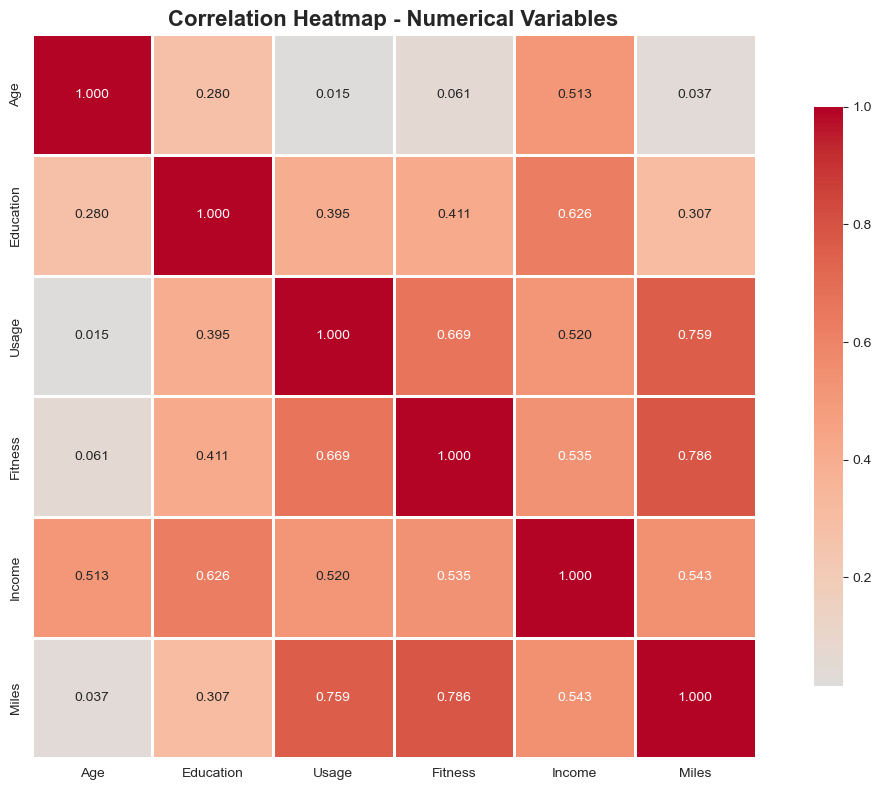

=== CORRELATION ANALYSIS ===

Correlations with Miles:
Fitness      0.785702
Usage        0.759130
Income       0.543473
Education    0.307284
Age          0.036618
Name: Miles, dtype: float64

Correlations with Miles for Age, Education, Usage:
Age: 0.0366
Education: 0.3073
Usage: 0.7591

*** STRONGEST POSITIVE CORRELATION: Usage (0.7591) ***


In [6]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Analysis - find strongest correlation with Miles
print("=== CORRELATION ANALYSIS ===")
if 'Miles' in correlation_matrix.columns:
    miles_correlations = correlation_matrix['Miles'].drop('Miles').sort_values(ascending=False)
    print("\nCorrelations with Miles:")
    print(miles_correlations)
    
    # Check specific variables
    variables_to_check = ['Age', 'Education', 'Usage']
    available_vars = [var for var in variables_to_check if var in miles_correlations.index]
    
    if available_vars:
        print(f"\nCorrelations with Miles for {', '.join(available_vars)}:")
        for var in available_vars:
            print(f"{var}: {miles_correlations[var]:.4f}")
        
        strongest_var = max(available_vars, key=lambda x: abs(miles_correlations[x]))
        print(f"\n*** STRONGEST POSITIVE CORRELATION: {strongest_var} ({miles_correlations[strongest_var]:.4f}) ***")

## Task 8: The Scatter Plot - Predicting the Future

**The Big Question:** Can we predict Miles based on Usage?

This is where statistics gets cool. We're going to draw a line through our data that best predicts the relationship between how often someone uses the equipment (Usage) and how many miles they log (Miles).

**What we're doing:**
- Plotting each customer as a dot (Usage on X-axis, Miles on Y-axis)
- Drawing a "best fit" line through the dots (the regression line)
- Calculating how good our prediction is (R² score)

**The Regression Line:**
This line is like a fortune teller. Give it a Usage value, and it predicts the Miles. The equation looks like:
```
Miles = (Slope × Usage) + Intercept
```

**Understanding the Slope:**
If the slope is 25, it means: "For every 1 extra time per week someone uses the equipment, they log 25 more miles on average."

**The R² Score:**
- R² = 1.0: Perfect prediction (all dots on the line)
- R² = 0.5: Decent prediction (explains 50% of the variation)
- R² = 0.0: Terrible prediction (the line is useless)

**Why this matters:**
If we can predict Miles from Usage, we can identify customers who should be logging more miles but aren't. Maybe they need encouragement or their equipment needs maintenance!

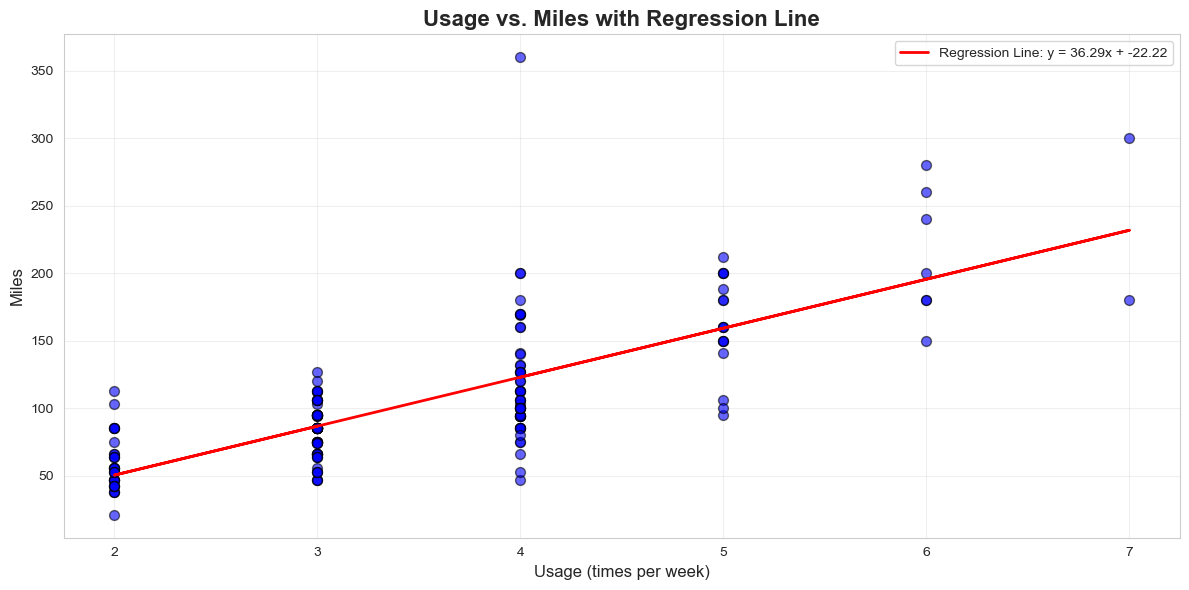

=== REGRESSION ANALYSIS ===
Slope (coefficient): 36.2936
Intercept: -22.2203
R² Score: 0.5763

Interpretation: For every 1 unit increase in Usage, Miles increases by 36.29 units.


In [7]:
# Prepare data
X = df['Usage'].values.reshape(-1, 1)
y = df['Miles'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Create scatter plot with regression line
plt.figure(figsize=(12, 6))
plt.scatter(df['Usage'], df['Miles'], alpha=0.6, color='blue', edgecolors='black', s=50)
plt.plot(df['Usage'], y_pred, color='red', linewidth=2, label=f'Regression Line: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
plt.title('Usage vs. Miles with Regression Line', fontsize=16, fontweight='bold')
plt.xlabel('Usage (times per week)', fontsize=12)
plt.ylabel('Miles', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display regression statistics
r2 = r2_score(y, y_pred)
print("=== REGRESSION ANALYSIS ===")
print(f"Slope (coefficient): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation: For every 1 unit increase in Usage, Miles increases by {model.coef_[0]:.2f} units.")

## The Final Task: Elite Athlete Profile - Who Are the Champions?

**The Big Question:** What makes an elite athlete customer different from everyone else?

We're filtering for customers with a Fitness Score of 5 (the highest level) and creating their "average profile." Think of this as building a persona for your most dedicated customers.

**What we're calculating:**
- Average Age: How old are elite athletes?
- Average Education: How many years of schooling?
- Average Income: How much do they earn?

**Why this matters:**
Understanding your best customers helps you:
- **Find more like them:** Target similar demographics
- **Keep them happy:** Design products for their needs
- **Learn from them:** What motivates peak performance?

**The Comparison:**
We'll compare elite athletes to the general customer base. Are they younger? Richer? More educated? These insights are gold for marketing and product development!

**Business Application:**
If elite athletes are 30 years old, earn $80K, and have 16 years of education, you know exactly who to target with your premium products and advanced training programs.


=== ELITE ATHLETE ANALYSIS ===
Total customers with Fitness Score = 5: 31
Percentage of total customers: 17.22%

=== AVERAGE PROFILE OF ELITE ATHLETES (Fitness = 5) ===
Average Age: 29.81 years
Average Education: 17.06 years
Average Income: $74,396.71

=== ADDITIONAL INSIGHTS ===
Average Usage: 4.84 times per week
Average Miles: 178.94


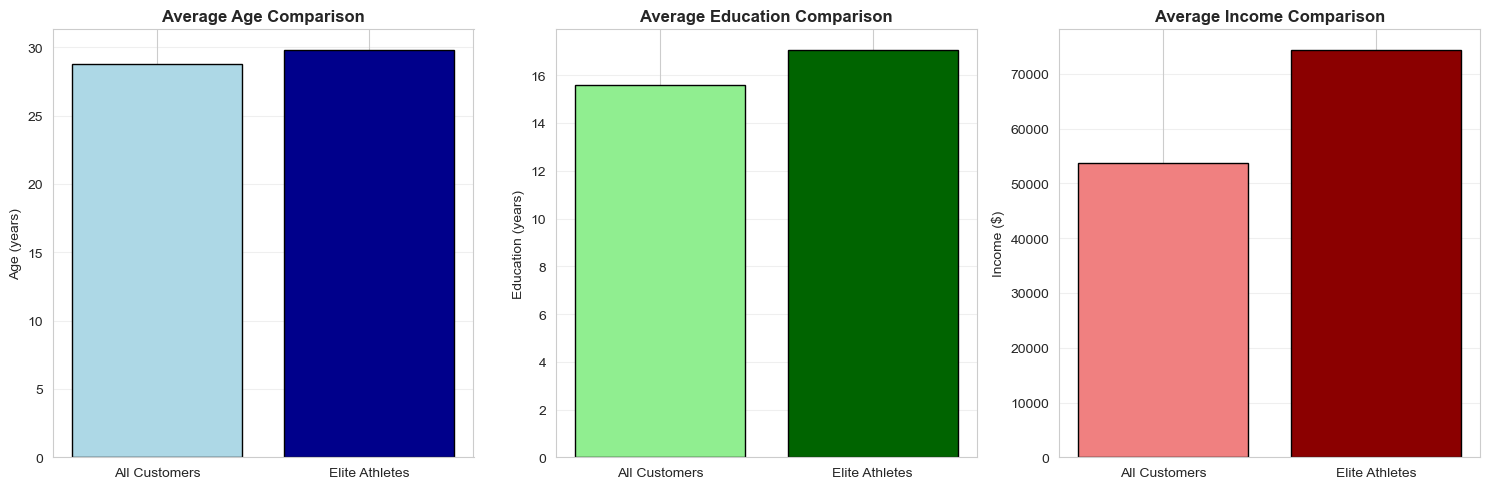


=== ANALYSIS COMPLETE ===


In [8]:
# Filter for elite athletes (Fitness Score = 5)
elite_athletes = df[df['Fitness'] == 5]

print("=== ELITE ATHLETE ANALYSIS ===")
print(f"Total customers with Fitness Score = 5: {len(elite_athletes)}")
print(f"Percentage of total customers: {len(elite_athletes)/len(df)*100:.2f}%")

# Calculate average profile
avg_age = elite_athletes['Age'].mean()
avg_education = elite_athletes['Education'].mean()
avg_income = elite_athletes['Income'].mean()

print("\n=== AVERAGE PROFILE OF ELITE ATHLETES (Fitness = 5) ===")
print(f"Average Age: {avg_age:.2f} years")
print(f"Average Education: {avg_education:.2f} years")
print(f"Average Income: ${avg_income:,.2f}")

# Additional insights
print("\n=== ADDITIONAL INSIGHTS ===")
if 'Usage' in elite_athletes.columns:
    print(f"Average Usage: {elite_athletes['Usage'].mean():.2f} times per week")
if 'Miles' in elite_athletes.columns:
    print(f"Average Miles: {elite_athletes['Miles'].mean():.2f}")

# Visualize elite athlete profile
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age comparison
axes[0].bar(['All Customers', 'Elite Athletes'], 
            [df['Age'].mean(), avg_age], 
            color=['lightblue', 'darkblue'], edgecolor='black')
axes[0].set_title('Average Age Comparison', fontweight='bold')
axes[0].set_ylabel('Age (years)')
axes[0].grid(True, alpha=0.3, axis='y')

# Education comparison
axes[1].bar(['All Customers', 'Elite Athletes'], 
            [df['Education'].mean(), avg_education], 
            color=['lightgreen', 'darkgreen'], edgecolor='black')
axes[1].set_title('Average Education Comparison', fontweight='bold')
axes[1].set_ylabel('Education (years)')
axes[1].grid(True, alpha=0.3, axis='y')

# Income comparison
axes[2].bar(['All Customers', 'Elite Athletes'], 
            [df['Income'].mean(), avg_income], 
            color=['lightcoral', 'darkred'], edgecolor='black')
axes[2].set_title('Average Income Comparison', fontweight='bold')
axes[2].set_ylabel('Income ($)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n=== ANALYSIS COMPLETE ===")